# House Price Prediction with Linear Regression

## Objective

Build and evaluate a Linear Regression model to predict house prices using selected property features.

## Workflow

- Data loading and EDA
- Feature selection
- Missing value handling and One-Hot Encoding
- Correlation analysis
- Train-test split
- Linear Regression
- Model evaluation
- Prediction and residual analysis
- Coefficient analysis
- Ridge Regression comparison

## Import Libraries


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [18]:
df = pd.read_csv("../Data/Raw/train.csv")

## Initial Data Inspection

In [19]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [20]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [21]:
df.shape

(1460, 81)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [23]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## Descriptive Statistics

In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


## SalePrice Distribution

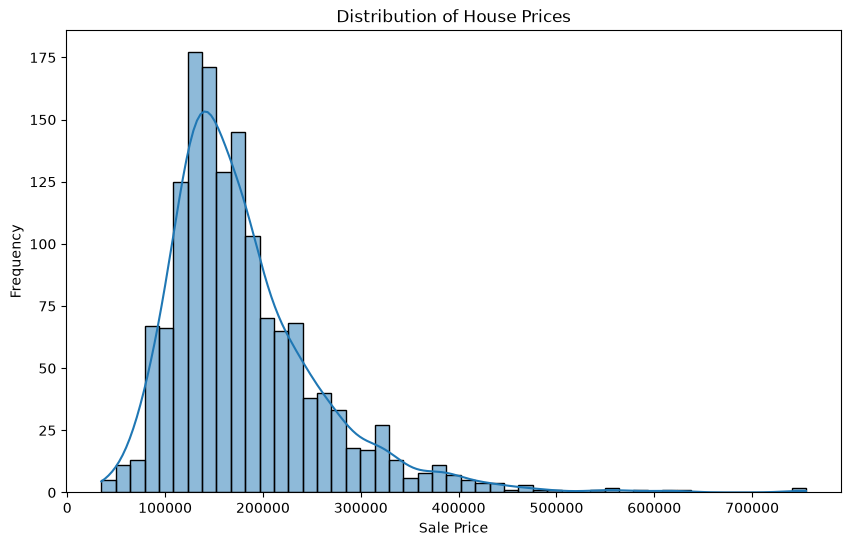

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

## Feature Selection

The selected features are OverallQual, GrLivArea, GarageCars, TotalBsmtSF, YearBuilt, and Neighborhood. These features represent house quality, living area, garage capacity, basement area, property age, and location, which are likely to influence house prices.

In [28]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt",
    "Neighborhood"
]

X = df[features]
y = df["SalePrice"]

X.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,Neighborhood
0,7,1710,2,856,2003,CollgCr
1,6,1262,2,1262,1976,Veenker
2,7,1786,2,920,2001,CollgCr
3,7,1717,3,756,1915,Crawfor
4,8,2198,3,1145,2000,NoRidge


## Data Preparation & Handling Missing Values

In [29]:
numeric_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "YearBuilt"
]

categorical_features = [
    "Neighborhood"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Correlation Analysis

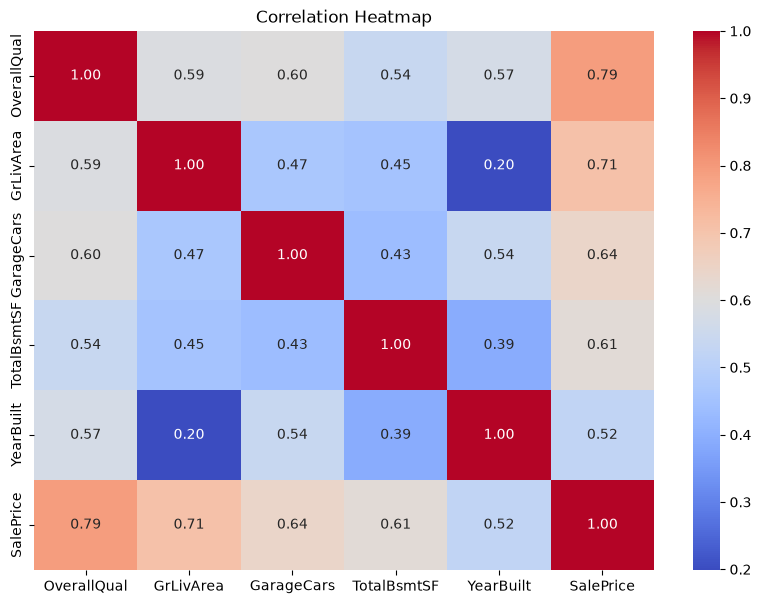

In [32]:
correlation_data = df[
    [
        "OverallQual",
        "GrLivArea",
        "GarageCars",
        "TotalBsmtSF",
        "YearBuilt",
        "SalePrice"
    ]
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_data,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

OverallQual has the strongest correlation with SalePrice (0.79), followed by GrLivArea (0.71), GarageCars (0.64), and TotalBsmtSF (0.61). YearBuilt also shows a positive relationship with SalePrice (0.52).

## Train-Test Split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

Training Features: (1168, 6)
Testing Features: (292, 6)


## Linear Regression Model

In [31]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


## Model Evaluation


In [33]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

evaluation_results = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R² Score"],
    "Value": [mse, rmse, r2]
})

evaluation_results

,Metric,Value
0,MSE,1.329312e+09
1,RMSE,3.645974e+04
2,R² Score,8.266942e-01


## Actual vs Predicted Prices

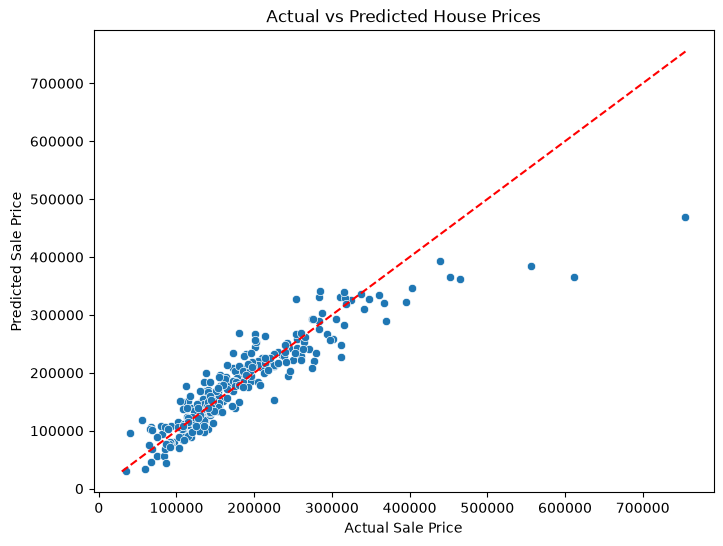

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test, y=y_pred)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color="red",
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.show()

Most predictions are close to the diagonal line, indicating good agreement between actual and predicted prices. Some higher-priced houses are underpredicted, showing that the model has larger errors for a few expensive properties.

## Residual Analysis

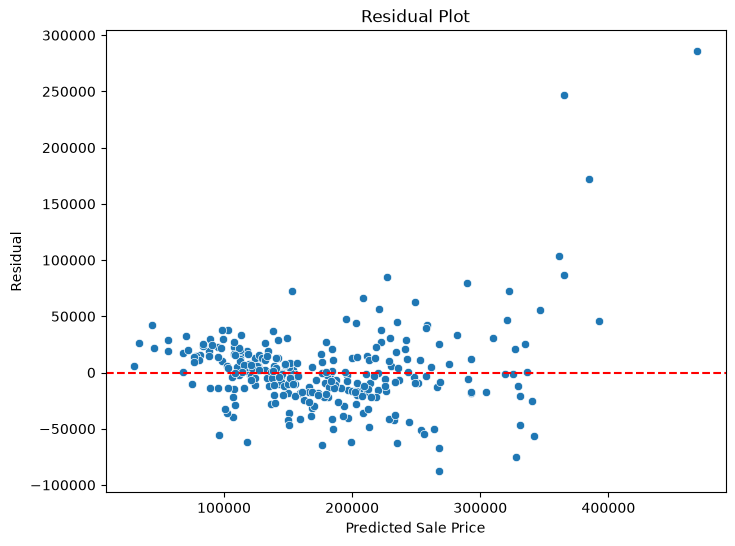

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")

plt.title("Residual Plot")
plt.xlabel("Predicted Sale Price")
plt.ylabel("Residual")

plt.show()

Most residuals are scattered around zero, although larger errors appear for some higher-priced houses. This indicates that the model performs reasonably well but has larger prediction errors for some expensive properties.

## Coefficient Analysis

In [36]:
feature_names = linear_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = linear_model.named_steps["model"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient")

coefficient_df

,Feature,Coefficient
7,cat__Neighborhood_BrDale,-39098.530176
18,cat__Neighborhood_NPkVill,-25385.741279
5,cat__Neighborhood_Blmngtn,-23638.773112
15,cat__Neighborhood_MeadowV,-19868.541346
22,cat__Neighborhood_OldTown,-18571.932316
12,cat__Neighborhood_Edwards,-15668.495780
19,cat__Neighborhood_NWAmes,-13839.985805
23,cat__Neighborhood_SWISU,-13503.730886
16,cat__Neighborhood_Mitchel,-12329.201086
6,cat__Neighborhood_Blueste,-12245.847012


## Highest Positive and Negative Impact

In [37]:
print("Highest Negative Impact:")
display(coefficient_df.head(5))

print("Highest Positive Impact:")
display(coefficient_df.tail(5).sort_values("Coefficient", ascending=False))

Highest Negative Impact:


,Feature,Coefficient
7,cat__Neighborhood_BrDale,-39098.530176
18,cat__Neighborhood_NPkVill,-25385.741279
5,cat__Neighborhood_Blmngtn,-23638.773112
15,cat__Neighborhood_MeadowV,-19868.541346
22,cat__Neighborhood_OldTown,-18571.932316


Highest Positive Impact:


,Feature,Coefficient
27,cat__Neighborhood_StoneBr,50197.560246
21,cat__Neighborhood_NridgHt,46122.163067
20,cat__Neighborhood_NoRidge,44903.366813
29,cat__Neighborhood_Veenker,39985.781462
9,cat__Neighborhood_ClearCr,24517.846635


## Ridge Regression Comparison

In [38]:
ridge_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MSE": [mse, ridge_mse],
    "RMSE": [rmse, ridge_rmse],
    "R² Score": [r2, ridge_r2]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,1.329312e+09,36459.735843,0.826694
1,Ridge Regression,1.559369e+09,39488.844889,0.796701


## Conclusion

The Linear Regression model achieved an R² score of 0.8267 with an RMSE of 36,459.74. OverallQual and GrLivArea showed strong relationships with SalePrice, while coefficient analysis highlighted the impact of neighborhood and other property features.

Ridge Regression achieved an R² score of 0.7967, which was lower than Linear Regression for this dataset. The Linear Regression model therefore performed better on the selected test data.